# Week 4 Day 2 Lab


### Problem 1: Random Data Set
1. Generate a data set of size 300 using `np.random` 
2. Save this data set as a pandas dataframe
3. Download the dataset as a csv using `dataframe_name.to_csv("file_name.csv", index=False)`

In [7]:
import numpy as np
import pandas as pd

x = np.random.rand(300)
df = pd.DataFrame(x, columns=["Random_Data"])
print(df.head())
df.to_csv("random_dataset.csv", index=False)

   Random_Data
0     0.410162
1     0.345178
2     0.750286
3     0.406918
4     0.056357


### Problem 2: Measures of Centrality
There are many ways to calculate what a data set is centered around. A few examples you have seen:

- Mean - The average of a dataset ($\bar{x}=\frac{1}{n}\sum\limits_{i=1}^nx_i$ for data points $x_i$)
- Median - The "middle data point" (average of 2 middle data points if data size is even-sized)
- Mode - The most common value (value with most number of occurences in data set)


1. Write your own function that calculate each of these.
2. Read the csv from Problem 1 into your notebook using `pd.read_csv("file_name.csv")`
3. Plot a histogram of the data and use `plt.axvline()` to plot vertical lines for the mean, median, and mode on the same histogram. 
4. Do you notice anything about the mean, median, and mode? How can you explain this behavior?

345.14285714285717
345.14285714285717
303
303


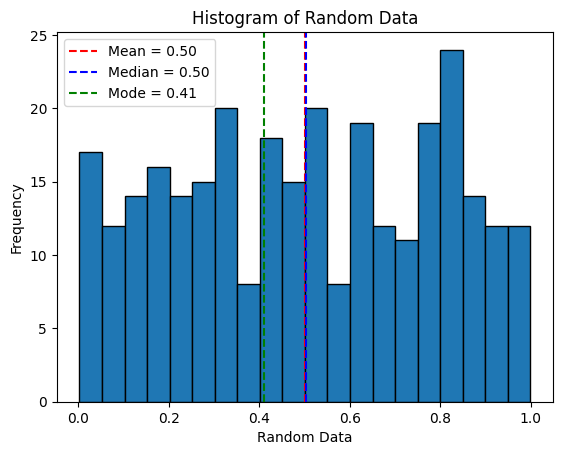

In [29]:
import matplotlib.pyplot as plt

def mean(data):
    sum = 0
    for x in data:
        sum += x
    return sum / len(data)

def median(data):
    data = sorted(data)
    size = len(data)
    index = int(size/2)
    if (size % 2 == 1):
        return data[index]
    else:
        return (data[index] + data[index - 1])/2

def mode(data):
    max = 0
    counts = {}
    result = None
    for x in data:
        if x not in counts:
            counts[x] = 1
        else:
            counts[x] += 1
            
        if (counts[x] > max):
            max = counts[x]
            result = x
    return result

x = [100,201,303,303,405,503,601]
print(np.mean(x))
print(mean(x))
print(median(x))
print(mode(x))


df = pd.read_csv("random_dataset.csv")
data = df["Random_Data"]

mean = mean(data)
median = median(data)
mode = mode(data)

plt.hist(data, bins=20, edgecolor="black")

plt.axvline(mean, color="red", linestyle="--", label=f"Mean = {mean:.2f}")
plt.axvline(median, color="blue", linestyle="--", label=f"Median = {median:.2f}")
plt.axvline(mode, color="green", linestyle="--", label=f"Mode = {mode:.2f}")

plt.xlabel("Random Data")
plt.ylabel("Frequency")
plt.title("Histogram of Random Data")
plt.legend()


# The mean median and mode are equal, while the mode is off by a bit. This is law of large numbers, the more samples the more the mean will converge to the true population mean. Since this is random, it is symmetrically distributed and will be equal to the median in theory. The mode is just pure chance, it could be any piece of data.

### Problem 3: Measures of Variability
We don't care solely where the data is centered, but also how spread out the data is around that center. Some ways we can measure this:
- Mean Absolute Deviation - Average of distance to the mean ($MAD(x)= \frac{1}{n}\sum\limits_{i=1}^n|x_i-\bar{x}|$)
- Variance - Average squared distance to the mean ($Var(x)=\frac{1}{n}\sum\limits_{i=1}^n(x_i-\bar{x})^2$)
- Standard Deviation - Square root of average squared distance to the mean ($s(x)=\sqrt{\frac{1}{n}\sum\limits_{i=1}^n(x_i-\bar{x})^2}$)

where $x$ is the entire dataset, $x_i$ is a data point, and $\bar{x}$ is the mean of the dataset.

1. Write your own function that calculate each of these.
2. Plot a histogram of the data and use `plt.axvline(mean + variance)` and `plt.axvline(mean-variance)` to plot vertical lines for variance on the same histogram. Do the same with adding and subtracting mean absolute deviation and standard deviation.
3. Do you notice anything about lines corresponding to the different definitions variability? How can you explain this behavior?

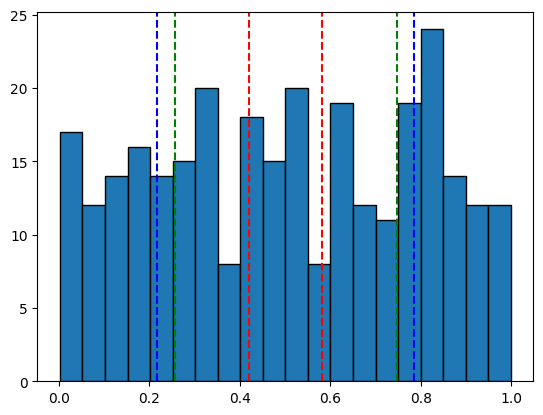

In [34]:
def mad(data):
    mean = np.mean(data)
    sum = 0
    for x in data:
        sum += abs(x - mean)
    return sum / len(data)

def var(data):
    mean = np.mean(data)
    sum = 0
    for x in data:
        sum += (x - mean)**2
    return sum / len(data)

def std(data):
    return (var(data))**0.5

df = pd.read_csv("random_dataset.csv")
data = df["Random_Data"]

m = np.mean(data)
v = var(data)
s = std(data)
d = mad(data)

plt.hist(data, bins=20, edgecolor="black")

plt.axvline(m + v, color="red", linestyle="--", label="Mean + Variance")
plt.axvline(m - v, color="red", linestyle="--", label="Mean - Variance")

plt.axvline(m + s, color="blue", linestyle="--", label="Mean + Std Dev")
plt.axvline(m - s, color="blue", linestyle="--", label="Mean - Std Dev")

plt.axvline(m + d, color="green", linestyle="--", label="Mean + MAD")
plt.axvline(m - d, color="green", linestyle="--", label="Mean - MAD")

# Variance is the smallest interval around the mean, MAD is next and standard deviation is largest. Variance is squared sums of the residuals, which is smaller here since differences are all less than 1 (the interval is 0 to 1). Standard deviation is largest since its the square root of this less than one number, on par with MAD since both are kind of on the same exponent level of one.